**Name: Sahil Suresh Ghogare**

**Roll no.: 23102A0061**

**Branch/ Div: BE CMPN A**

**R_Programming_Exp_1**

**Task-1: Import and Inspect the Dataset**

**Importing Dataset**

In [3]:
file_name <- "PRSA_Data_Aotizhongxin_20130301-20170228.csv"

**Reading Dataset with Error Handling**

In [4]:
air_data <- tryCatch(
{
  read.csv(file_name)
},
error = function(e)
{
  cat("Error:", e$message)
  NULL
})

**Displaying First Six Records**

In [5]:
head(air_data)

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>
1,1,2013,3,1,0,4,4,4,7,300,77,-0.7,1023.0,-18.8,0,NNW,4.4,Aotizhongxin
2,2,2013,3,1,1,8,8,4,7,300,77,-1.1,1023.2,-18.2,0,N,4.7,Aotizhongxin
3,3,2013,3,1,2,7,7,5,10,300,73,-1.1,1023.5,-18.2,0,NNW,5.6,Aotizhongxin
4,4,2013,3,1,3,6,6,11,11,300,72,-1.4,1024.5,-19.4,0,NW,3.1,Aotizhongxin
5,5,2013,3,1,4,3,3,12,12,300,72,-2.0,1025.2,-19.5,0,N,2.0,Aotizhongxin
6,6,2013,3,1,5,5,5,18,18,400,66,-2.2,1025.6,-19.6,0,N,3.7,Aotizhongxin


**Structure of Dataset**

In [6]:
str(air_data)

'data.frame':	35064 obs. of  18 variables:
 $ No     : int  1 2 3 4 5 6 7 8 9 10 ...
 $ year   : int  2013 2013 2013 2013 2013 2013 2013 2013 2013 2013 ...
 $ month  : int  3 3 3 3 3 3 3 3 3 3 ...
 $ day    : int  1 1 1 1 1 1 1 1 1 1 ...
 $ hour   : int  0 1 2 3 4 5 6 7 8 9 ...
 $ PM2.5  : num  4 8 7 6 3 5 3 3 3 3 ...
 $ PM10   : num  4 8 7 6 3 5 3 6 6 8 ...
 $ SO2    : num  4 4 5 11 12 18 18 19 16 12 ...
 $ NO2    : num  7 7 10 11 12 18 32 41 43 28 ...
 $ CO     : int  300 300 300 300 300 400 500 500 500 400 ...
 $ O3     : num  77 77 73 72 72 66 50 43 45 59 ...
 $ TEMP   : num  -0.7 -1.1 -1.1 -1.4 -2 -2.2 -2.6 -1.6 0.1 1.2 ...
 $ PRES   : num  1023 1023 1024 1024 1025 ...
 $ DEWP   : num  -18.8 -18.2 -18.2 -19.4 -19.5 -19.6 -19.1 -19.1 -19.2 -19.3 ...
 $ RAIN   : num  0 0 0 0 0 0 0 0 0 0 ...
 $ wd     : chr  "NNW" "N" "NNW" "NW" ...
 $ WSPM   : num  4.4 4.7 5.6 3.1 2 3.7 2.5 3.8 4.1 2.6 ...
 $ station: chr  "Aotizhongxin" "Aotizhongxin" "Aotizhongxin" "Aotizhongxin" ...


**Number of Rows and Columns**

In [7]:
dim(air_data)

[1] 35064    18

**Check Missing Values**

In [8]:
any(is.na(air_data))

[1] TRUE

**Total Missing Values**

In [9]:
sum(is.na(air_data))

[1] 7271

**Task-2: Understand NA, NULL, and NaN**

**Creating an NA Value**

In [10]:
temperature <- c(28, 30, NA, 32)
temperature

[1] 28 30 NA 32

Checking NA

In [11]:
is.na(temperature)

[1] FALSE FALSE  TRUE FALSE

**Creating a NULL Object**

In [12]:
missing_object <- NULL
missing_object

NULL

**Checking NULL**

In [13]:
is.null(missing_object)

[1] TRUE

**Creating a NaN Value**

In [14]:
undefined_value <- 0/0
undefined_value

[1] NaN

**Checking NaN**

In [15]:
is.nan(undefined_value)

[1] TRUE

**Comparing All Three**

In [16]:
cat("NA Check :", is.na(temperature[3]), "\n")
cat("NULL Check :", is.null(missing_object), "\n")
cat("NaN Check :", is.nan(undefined_value), "\n")

NA Check : TRUE 
NULL Check : TRUE 
NaN Check : TRUE 


**Task-3: Create a Missing Value Summary Function**

**Selecting Variables**

In [17]:
selected_variables <- c("PM2.5", "PM10", "SO2", "NO2", "TEMP", "WSPM", "wd")

**Creating missing_summary() Function**

In [20]:
missing_summary <- function(data)
{
  summary_table <- data.frame(
    Variable = character(),
    Total_Records = integer(),
    Missing_Values = integer(),
    Missing_Percentage = numeric(),
    stringsAsFactors = FALSE
  )

  for(var in selected_variables)
  {
    total <- nrow(data)
    missing <- sum(is.na(data[[var]]))
    percentage <- (missing / total) * 100

    summary_table <- rbind(
      summary_table,
      data.frame(
        Variable = var,
        Total_Records = total,
        Missing_Values = missing,
        Missing_Percentage = round(percentage,2)
      )
    )

    if(percentage > 20)
    {
      warning(paste(var, "contains more than 20% missing values"))
    }
  }

  return(summary_table)
}

**Calling the Function**

In [21]:
missing_table <- missing_summary(air_data)

missing_table

Variable,Total_Records,Missing_Values,Missing_Percentage
<chr>,<int>,<int>,<dbl>
PM2.5,35064,925,2.64
PM10,35064,718,2.05
SO2,35064,935,2.67
NO2,35064,1023,2.92
TEMP,35064,20,0.06
WSPM,35064,14,0.04
wd,35064,81,0.23


**Task-4: Identify Invalid Numerical Results**

**Creating pollution_ratio**

In [22]:
air_data$pollution_ratio <- air_data$PM2.5 / air_data$PM10

**Counting NA Values**

In [23]:
sum(is.na(air_data$pollution_ratio))

[1] 934

**Counting NaN Values**

In [24]:
sum(is.nan(air_data$pollution_ratio))

[1] 0

**Counting Infinite Values**

In [25]:
sum(is.infinite(air_data$pollution_ratio))

[1] 0

**Replacing NaN and Infinite Values with NA**

In [26]:
air_data$pollution_ratio[
  is.nan(air_data$pollution_ratio) |
  is.infinite(air_data$pollution_ratio)
] <- NA

**Verifying After Replacement**

In [27]:
cat("NA Values :", sum(is.na(air_data$pollution_ratio)), "\n")
cat("NaN Values :", sum(is.nan(air_data$pollution_ratio)), "\n")
cat("Infinite Values :", sum(is.infinite(air_data$pollution_ratio)), "\n")

NA Values : 934 
NaN Values : 0 
Infinite Values : 0 


**Task-5: Handle Missing Numerical Values Using a Loop**

**Creating Vector of Numerical Variables**

In [28]:
numeric_variables <- c("PM2.5", "PM10", "SO2", "NO2", "TEMP", "WSPM")

**Loop to Replace Missing Values with Median**

In [29]:
for(var in numeric_variables)
{
  if(var %in% names(air_data))
  {
    before <- sum(is.na(air_data[[var]]))

    median_value <- median(air_data[[var]], na.rm = TRUE)

    air_data[[var]][is.na(air_data[[var]])] <- median_value

    after <- sum(is.na(air_data[[var]]))

    cat("\nVariable :", var, "\n")
    cat("Missing Before :", before, "\n")
    cat("Median Used :", median_value, "\n")
    cat("Missing After :", after, "\n")
  }
}


Variable : PM2.5 
Missing Before : 925 
Median Used : 58 
Missing After : 0 

Variable : PM10 
Missing Before : 718 
Median Used : 87 
Missing After : 0 

Variable : SO2 
Missing Before : 935 
Median Used : 9 
Missing After : 0 

Variable : NO2 
Missing Before : 1023 
Median Used : 53 
Missing After : 0 

Variable : TEMP 
Missing Before : 20 
Median Used : 14.5 
Missing After : 0 

Variable : WSPM 
Missing Before : 14 
Median Used : 1.4 
Missing After : 0 


**Task-6: Handle Missing Categorical Values**

**Creating calculate_mode() Function**

In [30]:
calculate_mode <- function(x)
{
  unique_values <- unique(x[!is.na(x)])
  unique_values[which.max(tabulate(match(x, unique_values)))]
}

**Finding the Mode of wd**

In [31]:
mode_wd <- calculate_mode(air_data$wd)

mode_wd

[1] "NE"

**Counting Missing Values Before Replacement**

In [32]:
before <- sum(is.na(air_data$wd))

before

[1] 81

**Replacing Missing Values with Mode**

In [33]:
air_data$wd[is.na(air_data$wd)] <- mode_wd

**Counting Missing Values After Replacement**

In [34]:
after <- sum(is.na(air_data$wd))

after

[1] 0

**Displaying Summary**

In [35]:
cat("Mode of wd :", mode_wd, "\n")
cat("Missing Before :", before, "\n")
cat("Missing After :", after, "\n")

Mode of wd : NE 
Missing Before : 81 
Missing After : 0 


**Task-7: Implement Error Handling**

**Creating clean_variable() Function**

In [36]:
clean_variable <- function(data, variable_name)
{
  tryCatch({

    if(!(variable_name %in% names(data)))
      stop("Variable does not exist.")

    if(!is.numeric(data[[variable_name]]))
      stop("Variable is not numerical.")

    if(all(is.na(data[[variable_name]])))
      stop("Variable contains only missing values.")

    median_value <- median(data[[variable_name]], na.rm = TRUE)

    if(is.na(median_value))
      stop("Median cannot be calculated.")

    data[[variable_name]][is.na(data[[variable_name]])] <- median_value

    return(data[[variable_name]])

  },
  error = function(e)
  {
    cat("Error:", e$message, "\n")
    return(NULL)
  })
}

**Cleaning a Numerical Variable**

In [37]:
air_data$PM2.5 <- clean_variable(air_data, "PM2.5")

**Test: Variable Does Not Exist**

In [38]:
clean_variable(air_data, "ABC")

Error: Variable does not exist. 


NULL

**Test: Categorical Variable**

In [39]:
clean_variable(air_data, "wd")

Error: Variable is not numerical. 


NULL

**Verifying Missing Values After Cleaning**

In [40]:
sum(is.na(air_data$PM2.5))

[1] 0

**Task-8: Compare Missing Values Before and After Cleaning**

**Creating Comparison Table**

In [45]:
comparison_table <- data.frame(
  Variable = c("PM2.5", "PM10", "SO2", "NO2", "TEMP", "WSPM", "wd"),
  Missing_Before = c(925, 718, 935, 1023, 20, 14, 81),
  Missing_After = c(
    sum(is.na(air_data$PM2.5)),
    sum(is.na(air_data$PM10)),
    sum(is.na(air_data$SO2)),
    sum(is.na(air_data$NO2)),
    sum(is.na(air_data$TEMP)),
    sum(is.na(air_data$WSPM)),
    sum(is.na(air_data$wd))
  )
)

**Calculating Values Replaced**

In [46]:
comparison_table$Values_Replaced <-
  comparison_table$Missing_Before -
  comparison_table$Missing_After

**Displaying the Table**

In [47]:
comparison_table

Variable,Missing_Before,Missing_After,Values_Replaced
<chr>,<dbl>,<int>,<dbl>
PM2.5,925,0,925
PM10,718,0,718
SO2,935,0,935
NO2,1023,0,1023
TEMP,20,0,20
WSPM,14,0,14
wd,81,0,81


**Interpretation**

In [48]:
cat("Interpretation:\n")
cat("All selected variables were cleaned successfully.\n")
cat("Missing numerical values were replaced using the median,\n")
cat("and missing values in 'wd' were replaced using the mode.\n")
cat("The comparison table shows the reduction in missing values after cleaning.\n")

Interpretation:
All selected variables were cleaned successfully.
Missing numerical values were replaced using the median,
and missing values in 'wd' were replaced using the mode.
The comparison table shows the reduction in missing values after cleaning.


**Task-9: Generate One Visualzation**

**Creating Bar Chart**

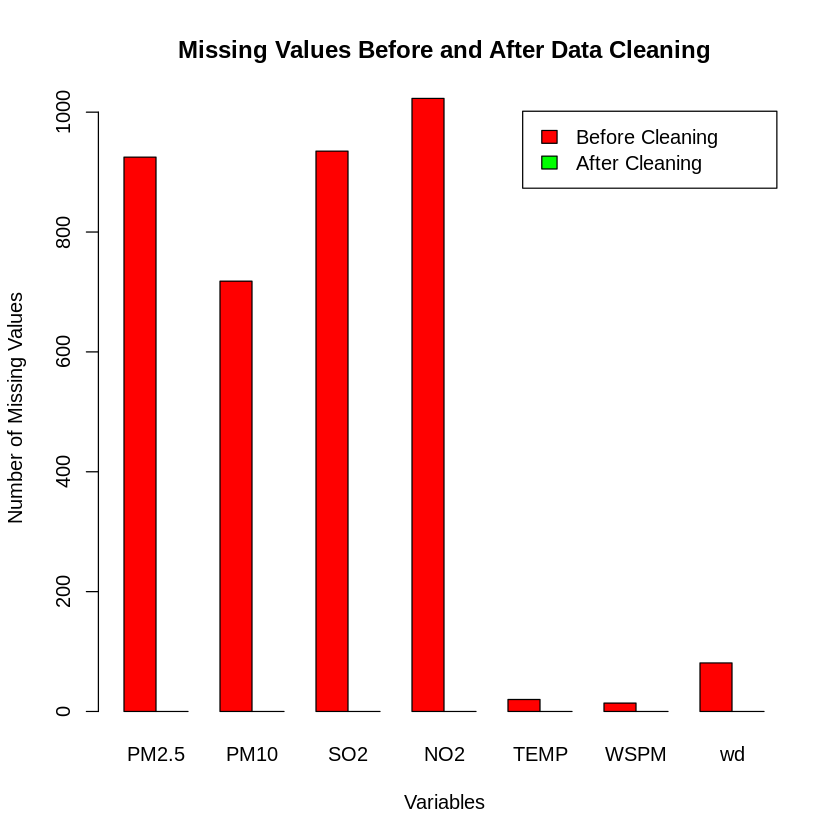

In [49]:
barplot(
  t(as.matrix(comparison_table[, c("Missing_Before", "Missing_After")])),
  beside = TRUE,
  names.arg = comparison_table$Variable,
  col = c("red", "green"),
  main = "Missing Values Before and After Data Cleaning",
  xlab = "Variables",
  ylab = "Number of Missing Values",
  legend.text = c("Before Cleaning", "After Cleaning")
)

**Task-10: Export the Cleaned Dataset**

**Exporting the Cleaned Dataset**

In [53]:
write.csv(
  air_data,
  "cleaned_air_quality_data.csv",
  row.names = FALSE
)

In [51]:
list.files()

[1] "cleaned_air_quality_data.csv"                
[2] "PRSA_Data_Aotizhongxin_20130301-20170228.csv"
[3] "sample_data"

The Beijing Air Quality dataset was successfully cleaned by identifying and handling missing and invalid values. Missing values in the numerical variables (PM2.5, PM10, SO2, NO2, TEMP, and WSPM) were replaced using the median, while missing values in the categorical variable wd were replaced using the mode. A new variable, pollution_ratio, was created, and any NaN or infinite values generated during the calculation were converted to NA for proper handling. User-defined functions, loops, and tryCatch() error handling were implemented to make the program efficient, reusable, and robust. A comparison of missing values before and after cleaning confirmed that all selected variables were successfully processed. The cleaned dataset was then exported as a CSV file, making it suitable for further statistical analysis, visualization, and machine learning applications.